In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize,StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.svm import LinearSVC

In [3]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/creditcard.csv"

# read the input data
raw_data=pd.read_csv(url)
raw_data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


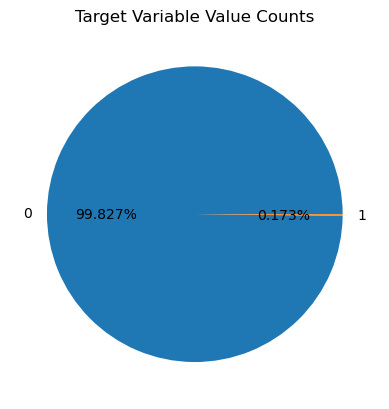

In [12]:
labels = raw_data.Class.unique()

size = raw_data.Class.value_counts().values

fig, ax = plt.subplots()
ax.pie(size, labels=labels, autopct='%1.3f%%')
ax.set_title('Target Variable Value Counts')
plt.show()

In [15]:
correlation_values = raw_data.corr()['Class'].drop('Class')
correlation_values.plot(kind='barh', figsize=(10, 6))

<Axes: >

In [16]:
raw_data.iloc[:,1:30] = StandardScaler().fit_transform(raw_data.iloc[:,1:30])
data_metrics = raw_data.values

In [19]:
X = data_metrics[:,1:30]
y = data_metrics[:, 30]
X = normalize(X,norm = 'l1')

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state = 42)
w_train = compute_sample_weight('balanced', y_train)

In [21]:
dt = DecisionTreeClassifier(max_depth = 4,random_state = 35)

In [23]:
dt.fit(X_train,y_train,sample_weight = w_train)

DecisionTreeClassifier(max_depth=4, random_state=35)

In [25]:
svm = LinearSVC(class_weight='balanced', random_state=31, loss="hinge", fit_intercept=False)
svm.fit(X_train,y_train)

LinearSVC(class_weight='balanced', fit_intercept=False, loss='hinge',
          random_state=31)

In [27]:
y_pred_dt = dt.predict_proba(X_test)[:,1]

In [28]:
roc_auc_dt = roc_auc_score(y_test, y_pred_dt)
print('Decision Tree ROC-AUC score : {0:.3f}'.format(roc_auc_dt))

Decision Tree ROC-AUC score : 0.939


In [32]:
roc_auc_svm = roc_auc_score(y_test, y_pred_svm)
print("SVM ROC-AUC score: {0:.3f}".format(roc_auc_svm))

SVM ROC-AUC score: 0.986


In [34]:
y_pred_sum = svm.decion_function(X_test) 

AttributeError: 'LinearSVC' object has no attribute 'decion_function'

In [36]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize,StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.svm import LinearSVC

url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/creditcard.csv"
# read the input data
raw_data=pd.read_csv(url)

labels = raw_data.Class.unique()
size = raw_data.Class.value_counts().values

correlation_values  = raw_data.corr()['Class'].drop('Class')

raw_data.iloc[:,0:30] = StandardScaler().fit_transform(raw_data.iloc[:,0:30])
data_matrix = raw_data.values

X =data_matrix[:,0:30]
y = data_matrix[:, 30]

X = normalize(X,norm = 'l1')
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state = 42)

w_train = compute_sample_weight('balanced',y_train)

dt = DecisionTreeClassifier(max_depth=4,random_state=42)
dt.fit(X_train,y_train,sample_weight = w_train)

svm = LinearSVC(loss = "hinge",fit_intercept=True,class_weight='balanced',random_state=42)
svm.fit(X_train,y_train)
y_pred_dt = dt.predict_proba(X_test)[:,1]
roc_auc_dt = roc_auc_score(y_test,y_pred_dt)
print(f"Decision Tree Accurcy:{0:.3f}".format(roc_auc_dt))

Decision Tree Accurcy:0.000


c:\Users\divya\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize,StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.svm import LinearSVC

url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/creditcard.csv"
# read the input data
raw_data=pd.read_csv(url)

labels = raw_data.Class.unique()
size = raw_data.Class.value_counts().values

correlation_values  = raw_data.corr()['Class'].drop('Class')

raw_data.iloc[:,0:30] = StandardScaler().fit_transform(raw_data.iloc[:,0:30])
data_matrix = raw_data.values

X =data_matrix[:,0:30]
y = data_matrix[:, 30]

X = normalize(X,norm = 'l1')
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state = 42)

w_train = compute_sample_weight('balanced',y_train)

dt = DecisionTreeClassifier(max_depth=4,random_state=42)
dt.fit(X_train,y_train,sample_weight = w_train)

svm = LinearSVC(loss = "hinge",fit_intercept=True,class_weight='balanced',random_state=42)
svm.fit(X_train,y_train)
y_pred_dt = dt.predict_proba(X_test)[:,1]
roc_auc_dt = roc_auc_score(y_test,y_pred_dt)
# print(f"Decision Tree Accurcy:{0:.3f}".format(roc_auc_dt))
y_pred_svm = svm.decision_function(X_test)
print(f"SUPPORT VECTORMACHINE ACCURACY:{0:.3f}".format(y_pred_svm))